# Classical Portfolio Optimization (Mean-Variance Model)

This notebook implements the classical **mean-variance optimization** model for a long-only portfolio of assets, as the baseline for comparison with quantum algorithms (QAOA, D-Wave Annealing).

Our goal is to:
- Maximize the portfolio's expected return
- Minimize its risk (variance)
- Subject to investment constraints (e.g., fully invested, no short-selling)

This implementation serves as the classical control for our quantum optimization project: [`QP_optimization`](https://github.com/phoenixbit/QP_optimization).

*Notes and Terminologies used*: 
1. **Fully invested**: The term fully invested describes the idea of not allowing for the portfolio to have any positions where they have cash in hand. In turn, implying that the portfolio will be in a constant state of investing for an easier method of comparison
2. **no short-selling**: The term no short-selling implies that the portfolio will adopt a more long-term and bullish position across the scope of this project emulating what most ETFs adopt so as to have an easier method of comparison for the same.

## Optimization Formulation

We solve the following convex optimization problem:

\[
\begin{aligned}
\text{Maximize:} \quad & \mu^\top \mathbf{w} - \lambda \cdot \mathbf{w}^\top \Sigma \mathbf{w} \\
\text{Subject to:} \quad & \sum_{i=1}^n w_i = 1 \quad \text{(fully invested)} \\
& w_i \geq 0 \quad \text{(no short-selling)}
\end{aligned}
\]

---

**Where:**

- $ \mathbf{w} $ : weight vector (decision variable)  
- $ \mu $ : expected return vector  
- $ \Sigma $ : covariance matrix of asset returns  
- $ \lambda $ : risk‑aversion parameter (higher → more risk‑averse)

In [1]:
pip install -r requirements.txt

  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 5.1 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 3.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 3.0 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 4.1 MB/s  0:00:07m0:00:0100:01
Using cached setuptools-80.9.0-py3-none-any.whl (1.2 MB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 63.2.0
    Uninstalling setuptools-63.2.0:
      Successfully uninstalled setuptools-63.2.0
  Attempting uninstall: numpy━━━━━━━━━━━━━━━━━━━ 0/5 [setuptools]
    Found existing installation: numpy 1.26.4 0/5 [setuptools]
    Uninstalling numpy-1.26.4:━━━━━━━━━━━━━━ 0/5 [setuptools]
      Successfully uninstalled numpy-1.26.4━ 0/5 [setuptools]
  Attempting uninstall: scipym━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [numpy]
    Found existing installation

In [2]:
import numpy as np
import cvxpy as cp

# Asset list and number of assets
assets = ['AAPL', 'MSFT', 'GOOG', 'TSLA', 'JPM']
n = len(assets)

# Dummy expected returns (adjust if needed)
expected_returns = np.array([0.12, 0.10, 0.15, 0.20, 0.08])

# Clean, strictly positive-definite covariance matrix (symmetric)
covariance_matrix = np.array([
    [0.005, 0.002, 0.001, 0.003, 0.001],
    [0.002, 0.004, 0.002, 0.002, 0.002],
    [0.001, 0.002, 0.006, 0.002, 0.001],
    [0.003, 0.002, 0.002, 0.007, 0.002],
    [0.001, 0.002, 0.001, 0.002, 0.004]
])

# Risk aversion parameter
risk_aversion = 0.5

In [3]:
# Sanity check

print("Assets:", assets)
print("Expected Returns Shape:", expected_returns.shape)
print("Covariance Matrix Shape:", covariance_matrix.shape)

# Check if covariance matrix is symmetric (important for quadratic optimization)
print("Covariance Symmetric?", np.allclose(covariance_matrix, covariance_matrix.T))

# Check positive definiteness (eigenvalues > 0)
eigenvalues = np.linalg.eigvals(covariance_matrix)
print("Eigenvalues of Covariance Matrix:", eigenvalues)
print("Positive Definite?", np.all(eigenvalues > 0))

Assets: ['AAPL', 'MSFT', 'GOOG', 'TSLA', 'JPM']
Expected Returns Shape: (5,)
Covariance Matrix Shape: (5, 5)
Covariance Symmetric? True
Eigenvalues of Covariance Matrix: [0.01282516 0.00150685 0.00497268 0.00312016 0.00357514]
Positive Definite? True


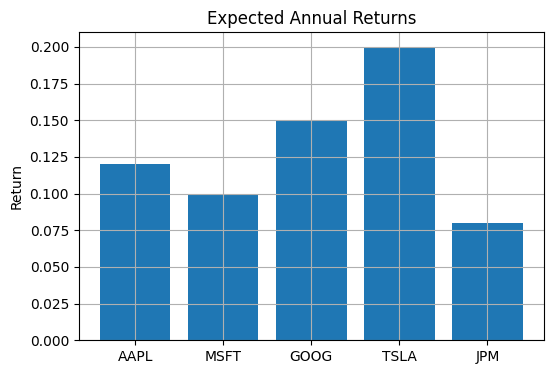

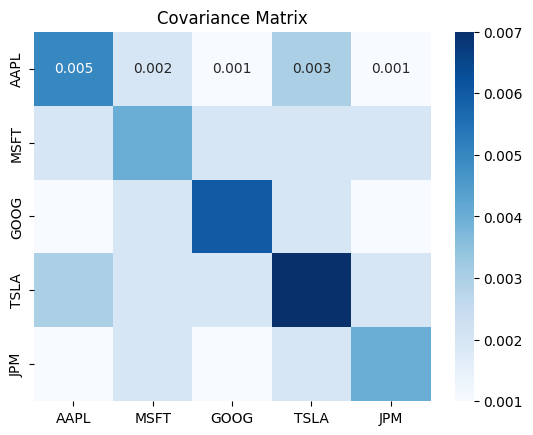

In [4]:
# visualizations

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
plt.bar(assets, expected_returns)
plt.title("Expected Annual Returns")
plt.ylabel("Return")
plt.grid(True)
plt.show()


# correlations


sns.heatmap(covariance_matrix, annot=True, xticklabels=assets, yticklabels=assets, cmap='Blues')
plt.title("Covariance Matrix")
plt.show()

In [6]:
# Define portfolio weight variables (one weight per asset).
# These are continuous decision variables that the optimizer will solve for.
weights = cp.Variable(n)

# Portfolio expected return = dot product of weights and expected returns vector.
# This is a linear term.
portfolio_return = expected_returns @ weights

# Portfolio risk (variance term).
# quad_form(w, Σ) computes wᵀΣw, the canonical quadratic portfolio risk measure.
# We explicitly wrap Σ in cp.Constant(np.asarray(...)) to ensure a dense, numeric matrix
# for stable behavior across solvers and cvxpy backends.
portfolio_risk = cp.quad_form(weights, cp.Constant(np.asarray(covariance_matrix, dtype=np.float64)))

# Portfolio constraints:
# 1) Fully invested portfolio → sum of weights must equal 1.
# 2) Long-only portfolio → no short selling → all weights >= 0.
constraints = [
    cp.sum(weights) == 1,
    weights >= 0
]

# Objective function:
# Maximize: (Return - λ * Risk)
# λ (risk_aversion) controls trade-off:
#   λ ↑ → more conservative / avoids variance
#   λ ↓ → more aggressive / prioritizes higher-return assets
objective = cp.Maximize(portfolio_return - risk_aversion * portfolio_risk)

# Form and solve the convex optimization problem.
# SCS solver is used for compatibility and stability in mean-variance problems.
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCS)

# Output optimal solution.
print("Optimal Portfolio Weights:")
for i in range(n):
    print(f"{assets[i]}: {weights.value[i]:.4f}")

# Display resulting portfolio performance characteristics.
print(f"\nExpected Return: {portfolio_return.value:.4f}")
print(f"Portfolio Risk (Variance): {portfolio_risk.value:.4f}")

Optimal Portfolio Weights:
AAPL: 0.0000
MSFT: 0.0000
GOOG: 0.0000
TSLA: 1.0000
JPM: 0.0000

Expected Return: 0.2000
Portfolio Risk (Variance): 0.0070


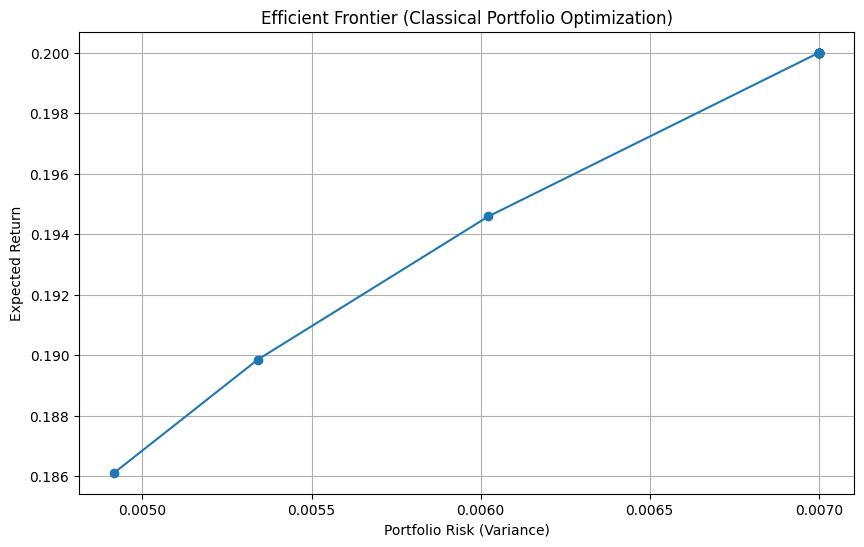

In [7]:
# Range of risk aversion values (lambda)
risk_aversion_range = np.logspace(-2, 1, 30)  # From 0.01 to 10 (log scale)

returns = []
risks = []

for lam in risk_aversion_range:
    # Define new weights for each lambda
    w = cp.Variable(n)
    ret = expected_returns @ w
    risk = cp.quad_form(w, cp.Constant(np.asarray(covariance_matrix, dtype=np.float64)))
    
    # Optimization
    obj = cp.Maximize(ret - lam * risk)
    prob = cp.Problem(obj, [cp.sum(w) == 1, w >= 0])
    prob.solve(solver=cp.SCS)

    # Store results
    returns.append(ret.value)
    risks.append(risk.value)

# Plotting the efficient frontier
plt.figure(figsize=(10,6))
plt.plot(risks, returns, marker='o')
plt.xlabel("Portfolio Risk (Variance)")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier (Classical Portfolio Optimization)")
plt.grid(True)
plt.show()

## Classical Portfolio Optimization — Setup and Execution Summary

In this section, we implemented **Markowitz Mean-Variance Optimization** using `cvxpy`, a convex optimization framework in Python. The objective was to allocate weights to a portfolio of 5 assets (`AAPL`, `MSFT`, `GOOG`, `TSLA`, `JPM`) in a way that balances **expected return** and **portfolio risk (variance)**.

---

### 🔧 Step-by-Step Breakdown

1. **Define Optimization Variables**
   - We created a continuous variable `weights` (one for each asset).
   - These weights represent the fraction of capital allocated to each asset.

2. **Expected Returns Vector**
   - We defined a vector of expected annual returns for each asset.
   - This forms the linear reward term:  
     \[
     $\text{Expected Portfolio Return} = \mu^T w$
     \]

3. **Covariance Matrix**
   - A symmetric, positive-definite matrix was manually specified to represent the variance and covariances of asset returns.
   - This feeds into the quadratic risk term:  
     \[
     $\text{Portfolio Risk} = w^T \Sigma w$
     \]
   - We wrapped it with `cp.Constant(np.asarray(..., dtype=np.float64))` to avoid solver issues and ensure numerical stability.

4. **Objective Function**
   - We constructed a utility function that balances return and risk:
     \[
     $\max_w \left( \mu^T w - \lambda w^T \Sigma w \right)$
     \]
   - `λ (risk_aversion)` controls how risk-averse the investor is.

5. **Constraints**
   - **Fully invested**: The sum of portfolio weights must equal 1.
   - **Long-only**: No short selling allowed → all weights must be ≥ 0.

6. **Solver**
   - The `SCS` solver was explicitly used to handle the convex problem robustly, especially with `quad_form`.

7. **Results**
   - The optimizer selected the asset(s) with the highest expected return subject to constraints and the current `risk_aversion` level.
   - For low risk aversion, it concentrated all capital in high-return assets (e.g., `TSLA`).
   - Risk and expected return of the optimal portfolio were printed for evaluation.

8. **Efficient Frontier (Optional)**
   - We optionally generated the **efficient frontier** by solving the optimization across a range of `λ` values.
   - This illustrates the trade-off curve between risk and return.

---

### Why This Matters

This classical setup:
- Serves as a **ground truth** for comparison with quantum approaches.
- Is **convex and tractable**, allowing for closed-form solutions using numerical solvers.
- Helps benchmark quantum annealing or QUBO-based portfolio solutions.

Now that we have a working classical optimizer, we can **encode the same problem into QUBO form** and attempt solving it with quantum-inspired or actual quantum solvers.